# A3 — Mini Project

Tie A1 + A2 together: ask a question about a dataset, answer it with **2 clearly-labelled matplotlib charts**, and write up what you found.

**This cell is your project README — fill it in (it's part of the grade):**

- **Question I'm exploring:** Did passenger class and age affect survival on the Titanic?
- **Dataset:** Titanic — 891 passengers (datasciencedojo CSV).
- **TL;DR finding:** Class and sex drove survival sharply; age barely mattered.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Reusing the Titanic data is totally fine (you can swap in another dataset if you want).
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Chart 1
Every chart MUST have: a **title**, an **x-axis label**, and a **y-axis label** (and a legend if you plot more than one series).
<br>Idea (pick your own): survival rate by `Pclass` as a bar chart. You already computed this number in A2 — now *show* it.
<br>Hint: a pandas Series has `.plot(kind='bar')`; or use `plt.bar(...)`. Then set `plt.title / plt.xlabel / plt.ylabel` and finish with `plt.show()`.

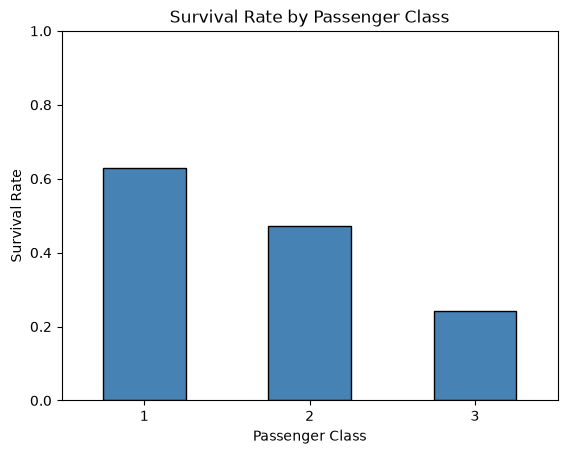

In [6]:
# TODO: chart 1 (with title + axis labels)
survival_by_class = df.groupby('Pclass')['Survived'].mean()

survival_by_class.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)          # keep class labels upright
plt.ylim(0, 1)                  # survival rate is a fraction, so cap at 1
plt.show()

## Chart 2
A different *kind* of chart than Chart 1 (so you practise two).
<br>Idea: a histogram of `Age` — the distribution you reasoned about in A2's median question. Does it actually look right-skewed?
<br>Hint: `plt.hist(...)` or `Series.plot(kind='hist')`. Label everything.

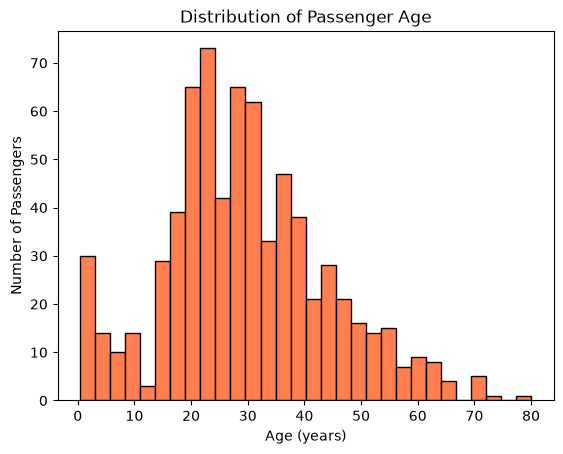

In [7]:
# TODO: chart 2 (with title + axis labels)

plt.hist(df['Age'], bins=30, color='coral', edgecolor='black')

plt.title('Distribution of Passenger Age')
plt.xlabel('Age (years)')
plt.ylabel('Number of Passengers')
plt.show()

## Findings
2–3 bullets in your own words: what do the charts show, and does it match what you expected from A2?

> _your findings here_
- Survival rate by class confirms the steep gradient I found in A2: 1st class survived at roughly 0.63, 2nd around 0.47, 3rd down near 0.24. Class clearly mattered — the higher your fare bracket, the better your odds — which matches the grouped means exactly.
- The age histogram is visibly right-skewed: most passengers cluster in their 20s–30s with a long thin tail toward the older ages and nothing below 0. This is what justified filling missing ages with the median rather than the mean in A2, since that right tail drags the mean upward.
- Overall the charts line up with the A2 numbers — nothing surprising. The one nuance the histogram adds is that age is fairly concentrated, which fits why age alone (unlike class or sex) wasn't a strong survival signal.